In [1]:
import os
import sys
import argparse

import numpy as np
import matplotlib.pyplot as plt

import torch

import dolfinx
import dolfinx.fem.petsc
import ufl
from mpi4py import MPI
import basix.ufl

repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)

from data_generation.differential_equations import ElasticityLeastSquares
from utils import load_yaml, load_pkl, load_npy, format_elapsed_time, timing, plot_complex_valued_function, plot_real_valued_function

from scifem import create_real_functionspace

import torch
import torch.nn as nn
import torch.nn.init as init
import numpy as np
from petsc4py import PETSc
import scifem


from utils import project, norm_L2, convert_petsc_mat_to_torch_sparse_coo_tensor
from typing import Optional
import pickle

from train.train_loss import SurrogateLoss
from tqdm import tqdm
from utils import project, norm_L2, convert_petsc_mat_to_torch_sparse_coo_tensor, convert_weight_to_tensor

----------------------------------------
2026-03-02 21:02:42 - Start Program
----------------------------------------


In [2]:
mesh_config_path= repo_path + "/configs/elasticity/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/elasticity/config_data/config_function_space.yaml"
output_reduced_basis_config_path= repo_path + "/configs/elasticity/config_data/config_output_reduced_basis.yaml"
train_dataset_path = repo_path + "/results/elasticity/train_dataset"
test_dataset_path = repo_path + "/results/elasticity/test_dataset"

mesh_args = load_yaml(mesh_config_path)
function_space_args = load_yaml(function_space_config_path)
output_reduced_basis_args = load_yaml(output_reduced_basis_config_path)
elasticity_least_squares = ElasticityLeastSquares(mesh_args, function_space_args)

In [3]:
p_dof = load_npy(train_dataset_path+'/p_dof.npy')
sigma_u_dof = load_npy(train_dataset_path+'/sigma_u_dof.npy')

In [4]:
print("p_dof shape: ", p_dof.shape)
print("sigma_u_dof shape: ", sigma_u_dof.shape)
# print("p_dof: ", p_dof)
# print("sigma_u_dof: ", sigma_u_dof)

p_dof shape:  (5000, 8385)
sigma_u_dof shape:  (5000, 230914)


In [5]:
mesh = elasticity_least_squares.mesh
Vh = elasticity_least_squares.Vh

In [6]:
dtype = torch.float64

In [7]:
pod_basis_dof = np.load(train_dataset_path+'/hdiv_h1_pod_basis_dof.npy')[:,:output_reduced_basis_args['num_basis']]
pod_coeff_labels = np.load(train_dataset_path+'/hdiv_h1_pod_coeff_labels.npy')[:,:output_reduced_basis_args['num_basis']]

In [8]:
pod_basis_dof = torch.tensor(pod_basis_dof, dtype=dtype)
pod_coeff_labels = torch.tensor(pod_coeff_labels, dtype=dtype)

quadratic_weight = torch.tensor(np.load(train_dataset_path+'/hdiv_h1_quadratic_weight.npy'), dtype=dtype)
linear_weight = torch.tensor(np.load(train_dataset_path+'/hdiv_h1_linear_weight.npy'), dtype=dtype)
bias = torch.tensor(np.load(train_dataset_path+'/hdiv_h1_bias.npy'), dtype=dtype)

In [9]:
reduced_weight_list = []
for i in range(len(quadratic_weight)):
    reduced_weight = {}
    reduced_weight['quadratic'] = quadratic_weight[i]
    reduced_weight['linear'] = linear_weight[i]
    reduced_weight['bias'] = bias[i]
    reduced_weight_list.append(reduced_weight)

In [10]:
surrogate_loss = SurrogateLoss(reduced_weight_list)

In [11]:
num_samples_for_computing_reference_surrogate_loss = 500
num_basis_list = [2**i for i in range(10)]
print("num_basis_list:", num_basis_list)
reference_surrogate_loss_record = np.zeros((len(num_basis_list), num_samples_for_computing_reference_surrogate_loss))

num_basis_list: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]


In [12]:
start_index = 4500

In [13]:
for i, num_basis in enumerate(num_basis_list):
    for j, sample_index in enumerate(range(start_index, start_index + num_samples_for_computing_reference_surrogate_loss)):
        reference_loss = surrogate_loss(pod_coeff_labels[sample_index], sample_index, sub_dim=num_basis)
        reference_surrogate_loss_record[i, j] = reference_loss.item()

In [14]:
avg_reference_surrogate_loss_record = np.mean(reference_surrogate_loss_record, axis=1)
max_reference_surrogate_loss_record = np.max(reference_surrogate_loss_record, axis=1)
std_reference_surrogate_loss_record = np.std(reference_surrogate_loss_record, axis=1)

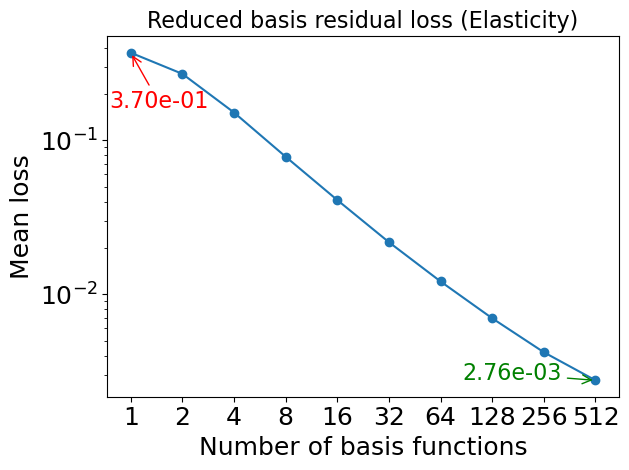

In [15]:
plt.plot(num_basis_list, avg_reference_surrogate_loss_record, marker='o')

plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xticks(num_basis_list, num_basis_list, fontsize=18)
plt.yticks(fontsize=18)

# Find smallest and largest y values and their x positions
y_vals = np.array(avg_reference_surrogate_loss_record)
x_vals = np.array(num_basis_list)

min_idx = np.argmin(y_vals)
max_idx = np.argmax(y_vals)

# Annotate smallest value
plt.annotate(
    f"{y_vals[min_idx]:.2e}",
    (x_vals[min_idx], y_vals[min_idx]),
    textcoords="offset points",
    xytext=(-60, 0),
    ha='center',
    color='green',
    fontsize=16,
    arrowprops=dict(arrowstyle="->", color='green')
)

# Annotate largest value
plt.annotate(
    f"{y_vals[max_idx]:.2e}",
    (x_vals[max_idx], y_vals[max_idx]),
    textcoords="offset points",
    xytext=(20, -40),
    ha='center',
    color='red',
    fontsize=16,
    arrowprops=dict(arrowstyle="->", color='red')
)

plt.xlabel('Number of basis functions', fontsize=18)
plt.ylabel('Mean loss', fontsize=18)
plt.title('Reduced basis residual loss (Elasticity)', fontsize=16)

plt.tight_layout()
plt.savefig('reduced_basis_residual_loss_elasticity.png')
plt.show()

In [16]:
print("avg_reference_surrogate_loss_record:", [f"{x:.2e}" for x in avg_reference_surrogate_loss_record])
print("std_reference_surrogate_loss_record:", [f"{x:.2e}" for x in std_reference_surrogate_loss_record])

avg_reference_surrogate_loss_record: ['3.70e-01', '2.70e-01', '1.51e-01', '7.82e-02', '4.09e-02', '2.18e-02', '1.21e-02', '6.99e-03', '4.21e-03', '2.76e-03']
std_reference_surrogate_loss_record: ['2.39e-01', '1.70e-01', '8.16e-02', '2.92e-02', '1.30e-02', '6.50e-03', '3.68e-03', '2.03e-03', '1.09e-03', '6.14e-04']


In [17]:
compute_squared_L2_norm = elasticity_least_squares.compute_squared_L2_norm
compute_squared_hdiv_h1_norm = elasticity_least_squares.compute_squared_hdiv_h1_norm

In [18]:
num_samples_for_computing_low_rank_approximation_error = 500

In [19]:
sigma_u_error_squared_L2_norm_record = np.zeros((len(num_basis_list), num_samples_for_computing_low_rank_approximation_error))
sigma_u_relative_error_squared_L2_norm_record = np.zeros((len(num_basis_list), num_samples_for_computing_low_rank_approximation_error))

In [20]:
sigma_u_squared_L2_norm_record = np.zeros(num_samples_for_computing_low_rank_approximation_error)
for j, sample_index in enumerate(tqdm(range(start_index, start_index + num_samples_for_computing_low_rank_approximation_error))):
    sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
    sigma_u_label_fc.x.array[:] = sigma_u_dof[sample_index]
    sigma_u_squared_L2_norm_record[j] = compute_squared_L2_norm(sigma_u_label_fc)
avg_sigma_u_squared_L2_norm = np.mean(sigma_u_squared_L2_norm_record)

100%|██████████| 500/500 [00:02<00:00, 168.19it/s]


In [21]:
for i, num_basis in enumerate(tqdm(num_basis_list)):
    low_rank_sigma_u_dof = pod_coeff_labels[start_index:start_index+num_samples_for_computing_low_rank_approximation_error, :num_basis] @ pod_basis_dof[:, :num_basis].T
    for j, sample_index in enumerate(tqdm(range(start_index, start_index + num_samples_for_computing_low_rank_approximation_error))):
        sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_label_fc.x.array[:] = sigma_u_dof[sample_index]

        sigma_u_low_rank_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_low_rank_fc.x.array[:] = low_rank_sigma_u_dof[j].numpy()

        sigma_u_error_squared_L2_norm_record[i, j] = compute_squared_L2_norm(sigma_u_label_fc - sigma_u_low_rank_fc)
        sigma_u_relative_error_squared_L2_norm_record[i, j] = sigma_u_error_squared_L2_norm_record[i, j] / avg_sigma_u_squared_L2_norm

100%|██████████| 10/10 [00:57<00:00,  5.71s/it]


In [22]:
sigma_u_error_L2_bochner_norm_record = np.sqrt(np.mean(sigma_u_error_squared_L2_norm_record, axis=1))
sigma_u_relative_error_L2_bochner_norm_record = np.sqrt(np.mean(sigma_u_relative_error_squared_L2_norm_record, axis=1))

In [23]:
std_sigma_u_error_L2_norm_record = np.std(np.sqrt(sigma_u_error_squared_L2_norm_record), axis=1)
std_sigma_u_relative_error_L2_norm_record = np.std(np.sqrt(sigma_u_relative_error_squared_L2_norm_record), axis=1)

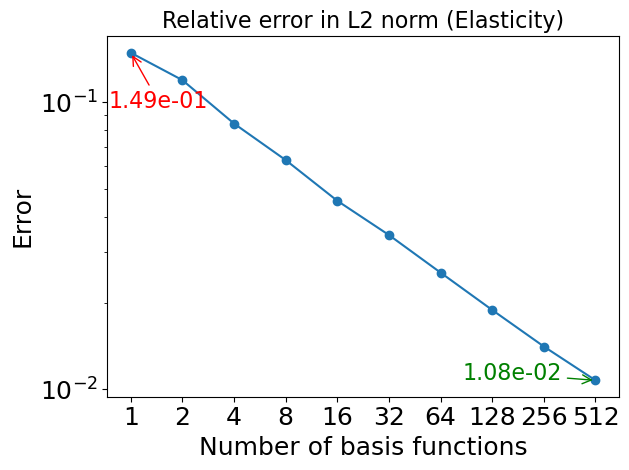

In [24]:
plt.plot(num_basis_list, sigma_u_relative_error_L2_bochner_norm_record, marker='o')

plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xticks(num_basis_list, num_basis_list, fontsize=18)
plt.yticks(fontsize=18)

# Find smallest and largest y values and their x positions
y_vals = np.array(sigma_u_relative_error_L2_bochner_norm_record)
x_vals = np.array(num_basis_list)

min_idx = np.argmin(y_vals)
max_idx = np.argmax(y_vals)

# Annotate smallest value
plt.annotate(
    f"{y_vals[min_idx]:.2e}",
    (x_vals[min_idx], y_vals[min_idx]),
    textcoords="offset points",
    xytext=(-60, 0),
    ha='center',
    color='green',
    fontsize=16,
    arrowprops=dict(arrowstyle="->", color='green')
)

# Annotate largest value
plt.annotate(
    f"{y_vals[max_idx]:.2e}",
    (x_vals[max_idx], y_vals[max_idx]),
    textcoords="offset points",
    xytext=(20, -40),
    ha='center',
    color='red',
    fontsize=16,
    arrowprops=dict(arrowstyle="->", color='red')
)

plt.xlabel('Number of basis functions', fontsize=18)
plt.ylabel('Error', fontsize=18)
plt.title('Relative error in L2 norm (Elasticity)', fontsize=16)

plt.tight_layout()
plt.savefig('relative_error_L2_norm_elasticity.png')
plt.show()

In [25]:
print("sigma_u_relative_error_L2_bochner_norm_record:", [f"{x:.2e}" for x in sigma_u_relative_error_L2_bochner_norm_record])
print("std_sigma_u_relative_error_L2_norm_record:", [f"{x:.2e}" for x in std_sigma_u_relative_error_L2_norm_record])    

sigma_u_relative_error_L2_bochner_norm_record: ['1.49e-01', '1.19e-01', '8.43e-02', '6.29e-02', '4.54e-02', '3.45e-02', '2.55e-02', '1.89e-02', '1.41e-02', '1.08e-02']
std_sigma_u_relative_error_L2_norm_record: ['5.19e-02', '3.98e-02', '2.36e-02', '1.74e-02', '1.10e-02', '7.91e-03', '5.65e-03', '4.00e-03', '2.90e-03', '2.13e-03']


In [26]:
sigma_u_error_squared_hdiv_h1_norm_record = np.zeros((len(num_basis_list), num_samples_for_computing_low_rank_approximation_error))
sigma_u_relative_error_squared_hdiv_h1_norm_record = np.zeros((len(num_basis_list), num_samples_for_computing_low_rank_approximation_error))

In [27]:
mean_p_fc = dolfinx.fem.Function(Vh['p'])
mean_p_fc.x.array[:] = np.load(os.path.join(train_dataset_path, 'mean_p_dof.npy'))

In [28]:
sigma_u_squared_hdiv_h1_norm_record = np.zeros(num_samples_for_computing_low_rank_approximation_error)
for j, sample_index in enumerate(tqdm(range(start_index, start_index + num_samples_for_computing_low_rank_approximation_error))):
    sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
    sigma_u_label_fc.x.array[:] = sigma_u_dof[sample_index]

    sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
    u_label_fc = sigma_u_label_fc.sub(1).collapse()
    sigma1_label_fc, sigma2_label_fc = ufl.split(sigma_label_fc)
    sigma_label_fc_ = ufl.as_vector((sigma1_label_fc, sigma2_label_fc))

    sigma_u_squared_hdiv_h1_norm_record[j] = compute_squared_hdiv_h1_norm(sigma_label_fc_, u_label_fc, mean_p_fc)
avg_sigma_u_squared_hdiv_h1_norm = np.mean(sigma_u_squared_hdiv_h1_norm_record)

100%|██████████| 500/500 [00:21<00:00, 23.38it/s]


In [29]:
for i, num_basis in enumerate(tqdm(num_basis_list)):
    low_rank_sigma_u_dof = pod_coeff_labels[start_index:start_index+num_samples_for_computing_low_rank_approximation_error, :num_basis] @ pod_basis_dof[:, :num_basis].T
    for j, sample_index in enumerate(tqdm(range(start_index, start_index + num_samples_for_computing_low_rank_approximation_error))):
        sigma_u_low_rank_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_low_rank_fc.x.array[:] = low_rank_sigma_u_dof[j].numpy()
        sigma_low_rank_fc = sigma_u_low_rank_fc.sub(0).collapse()
        u_low_rank_fc = sigma_u_low_rank_fc.sub(1).collapse()
        sigma1_low_rank_fc, sigma2_low_rank_fc = ufl.split(sigma_low_rank_fc)
        sigma_low_rank_fc_ = ufl.as_vector((sigma1_low_rank_fc, sigma2_low_rank_fc))


        sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_label_fc.x.array[:] = sigma_u_dof[sample_index]
        sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
        u_label_fc = sigma_u_label_fc.sub(1).collapse()
        sigma1_label_fc, sigma2_label_fc = ufl.split(sigma_label_fc)
        sigma_label_fc_ = ufl.as_vector((sigma1_label_fc, sigma2_label_fc))

        difference_sigma_fc = ufl.as_vector((sigma1_low_rank_fc - sigma1_label_fc, sigma2_low_rank_fc - sigma2_label_fc))
        difference_u_fc = u_low_rank_fc - u_label_fc

        sigma_u_error_squared_hdiv_h1_norm_record[i, j] = compute_squared_hdiv_h1_norm(difference_sigma_fc, difference_u_fc, mean_p_fc)
        sigma_u_relative_error_squared_hdiv_h1_norm_record[i, j] = sigma_u_error_squared_hdiv_h1_norm_record[i, j] / avg_sigma_u_squared_hdiv_h1_norm

100%|██████████| 10/10 [06:00<00:00, 36.02s/it]


In [30]:
sigma_u_error_hdiv_h1_bochner_norm_record = np.sqrt(np.mean(sigma_u_error_squared_hdiv_h1_norm_record, axis=1))
sigma_u_relative_error_hdiv_h1_bochner_norm_record = np.sqrt(np.mean(sigma_u_relative_error_squared_hdiv_h1_norm_record, axis=1))

In [31]:
std_sigma_u_error_hdiv_h1_norm_record = np.std(np.sqrt(sigma_u_error_squared_hdiv_h1_norm_record), axis=1) 
std_sigma_u_relative_error_hdiv_h1_norm_record = np.std(np.sqrt(sigma_u_relative_error_squared_hdiv_h1_norm_record), axis=1)

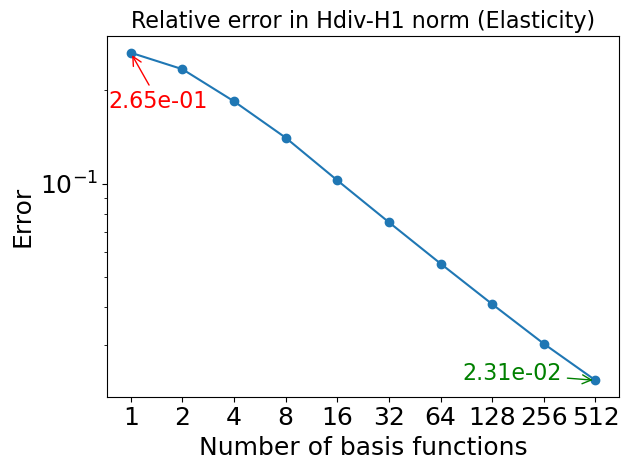

In [32]:
plt.plot(num_basis_list, sigma_u_relative_error_hdiv_h1_bochner_norm_record, marker='o')

plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xticks(num_basis_list, num_basis_list, fontsize=18)
plt.yticks(fontsize=18)

# Find smallest and largest y values and their x positions
y_vals = np.array(sigma_u_relative_error_hdiv_h1_bochner_norm_record)
x_vals = np.array(num_basis_list)

min_idx = np.argmin(y_vals)
max_idx = np.argmax(y_vals)

# Annotate smallest value
plt.annotate(
    f"{y_vals[min_idx]:.2e}",
    (x_vals[min_idx], y_vals[min_idx]),
    textcoords="offset points",
    xytext=(-60, 0),
    ha='center',
    color='green',
    fontsize=16,
    arrowprops=dict(arrowstyle="->", color='green')
)

# Annotate largest value
plt.annotate(
    f"{y_vals[max_idx]:.2e}",
    (x_vals[max_idx], y_vals[max_idx]),
    textcoords="offset points",
    xytext=(20, -40),
    ha='center',
    color='red',
    fontsize=16,
    arrowprops=dict(arrowstyle="->", color='red')
)

plt.xlabel('Number of basis functions', fontsize=18)
plt.ylabel('Error', fontsize=18)
plt.title('Relative error in Hdiv-H1 norm (Elasticity)', fontsize=16)

plt.tight_layout()
plt.savefig('relative_error_hdiv_h1_norm_elasticity.png')
plt.show()

In [33]:
print("sigma_u_relative_error_hdiv_h1_bochner_norm_record:", [f"{x:.2e}" for x in sigma_u_relative_error_hdiv_h1_bochner_norm_record])
print("std_sigma_u_relative_error_hdiv_h1_norm_record:", [f"{x:.2e}" for x in std_sigma_u_relative_error_hdiv_h1_norm_record])

sigma_u_relative_error_hdiv_h1_bochner_norm_record: ['2.65e-01', '2.34e-01', '1.84e-01', '1.41e-01', '1.02e-01', '7.50e-02', '5.52e-02', '4.08e-02', '3.04e-02', '2.31e-02']
std_sigma_u_relative_error_hdiv_h1_norm_record: ['5.32e-02', '4.71e-02', '3.28e-02', '2.37e-02', '1.45e-02', '1.01e-02', '7.41e-03', '5.44e-03', '4.05e-03', '3.11e-03']


In [34]:
mean_p_fc

Coefficient(FunctionSpace(Mesh(blocked element (Basix element (P, triangle, 1, gll_warped, unset, False, float64, []), (2,)), 0), Basix element (P, triangle, 1, gll_warped, unset, False, float64, [])), 10500)

In [35]:
new_num_basis_list = [2, 8, 32, 128, 512]
sample_index = start_index + 10

for i, num_basis in enumerate(new_num_basis_list):
    label_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
    label_sigma_u_fc.x.array[:] = sigma_u_dof[sample_index]
    label_sigma_fc = label_sigma_u_fc.sub(0).collapse()
    label_u_fc = label_sigma_u_fc.sub(1).collapse()
    label_sigma1_fc, label_sigma2_fc = ufl.split(label_sigma_fc)
    label_sigma_fc_ = ufl.as_vector((label_sigma1_fc, label_sigma2_fc))

 
    low_rank_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
    low_rank_sigma_u_fc.x.array[:] = pod_coeff_labels[sample_index, :num_basis] @ pod_basis_dof[:, :num_basis].T
    low_rank_sigma_fc = low_rank_sigma_u_fc.sub(0).collapse()
    low_rank_u_fc = low_rank_sigma_u_fc.sub(1).collapse()
    low_rank_sigma1_fc, low_rank_sigma2_fc = ufl.split(low_rank_sigma_fc)
    low_rank_sigma_fc_ = ufl.as_vector((low_rank_sigma1_fc, low_rank_sigma2_fc))

    print("")
    print(f'num_basis: {num_basis}')
    squared_hdiv_h1_error = compute_squared_hdiv_h1_norm(low_rank_sigma_fc_ - label_sigma_fc_, low_rank_u_fc - label_u_fc, mean_p_fc)

    print(f'squared Hdiv-H1 error: {squared_hdiv_h1_error:.2e}')


    p_fc = dolfinx.fem.Function(Vh['p'])  
    p_fc.x.array[:] = p_dof[sample_index]
    weight = elasticity_least_squares.compute_weight(p_fc)
    weight_tensor = convert_weight_to_tensor(weight, dtype=torch.float64)

    y = pod_coeff_labels[sample_index, :num_basis] @ pod_basis_dof[:, :num_basis].T
    y = torch.tensor(y, dtype=torch.float64)
    low_rank_reference_loss = torch.dot(y, weight_tensor['A00'] @ y) + 2*torch.dot(y, weight_tensor['A01'])  + weight_tensor['A11']
    print(f'low rank reference loss: {low_rank_reference_loss.item()}')

    
    y = sigma_u_dof[sample_index]
    y = torch.tensor(y, dtype=torch.float64)
    label_reference_loss = torch.dot(y, weight_tensor['A00'] @ y) + 2*torch.dot(y, weight_tensor['A01'])  + weight_tensor['A11']
    print(f'label reference loss: {label_reference_loss.item()}')

    print(f'gap between low rank reference loss and label reference loss: {(low_rank_reference_loss.item() - label_reference_loss.item()):.2e}')


num_basis: 2
squared Hdiv-H1 error: 2.91e-01
low rank reference loss: 0.7283433124110074
label reference loss: 0.0008723692094697588
gap between low rank reference loss and label reference loss: 7.27e-01

num_basis: 8
squared Hdiv-H1 error: 6.79e-02
low rank reference loss: 0.09223716107726754
label reference loss: 0.0008723692094697588
gap between low rank reference loss and label reference loss: 9.14e-02

num_basis: 32
squared Hdiv-H1 error: 1.72e-02
low rank reference loss: 0.01900635551536345
label reference loss: 0.0008723692094697588
gap between low rank reference loss and label reference loss: 1.81e-02

num_basis: 128
squared Hdiv-H1 error: 7.60e-03
low rank reference loss: 0.009241743551444248
label reference loss: 0.0008723692094697588
gap between low rank reference loss and label reference loss: 8.37e-03

num_basis: 512
squared Hdiv-H1 error: 2.26e-03
low rank reference loss: 0.003475141529722392
label reference loss: 0.0008723692094697588
gap between low rank reference loss